In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, callbacks,utils
from imblearn.over_sampling import ADASYN,SMOTE
from collections import Counter
from keras.optimizers import Adam

from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [2]:
df=pd.read_csv("cleaned_dataset_taiwan_2months.csv")

df.head()

,date,sitename,county,aqi,status,so2,co,o3,pm10,pm2.5,no2,nox,no,siteid
0,2024-08-31 23:00:00,Hukou,Hsinchu County,62.0,Moderate,0.9,0.17,35.0,18.0,17.0,2.3,2.6,0.3,22
1,2024-08-31 23:00:00,Zhongming,Taichung City,50.0,Good,1.6,0.32,27.9,27.0,14.0,7.6,9.3,1.6,31
2,2024-08-31 23:00:00,Zhudong,Hsinchu County,45.0,Good,0.4,0.17,25.1,21.0,13.0,2.9,4.1,1.1,23
3,2024-08-31 23:00:00,Hsinchu,Hsinchu City,42.0,Good,0.8,0.20,30.0,19.0,10.0,4.0,4.8,0.7,24
4,2024-08-31 23:00:00,Toufen,Miaoli County,50.0,Good,1.0,0.16,33.5,18.0,14.0,1.8,3.1,1.2,25


In [3]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['status']
X=df[features]
y=df[status]  


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)
y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=False)

In [6]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)

In [7]:
print(X_scaled.shape)

(100731, 8)


In [8]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), # Added for stability based on your previous design
    layers.Dropout(0.4),
    
    # Second GRU layer
    layers.GRU(64, return_sequences=True),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Second GRU layer
    layers.GRU(32),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [10]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_rf_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [11]:

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weights_dict = dict(enumerate(weights))

In [12]:
def create_sequences(data, labels, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        # Extract the window of 24 hours
        X.append(data[i:(i + window_size)])
        # The target is the air quality status at the end of that window
        y.append(labels[i + window_size])
    return np.array(X), np.array(y)

# Transform your balanced, scaled data into 3D sequences
X_train_seq, y_train_seq = create_sequences(X_scaled, y_train, window_size=24)

In [13]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
class_weight=class_weights_dict,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 44s 120ms/step - accuracy: 0.4265 - loss: 1.2513 - precision: 0.4384 - recall: 0.3588 - val_accuracy: 0.6018 - val_loss: 0.9042 - val_precision: 0.6529 - val_recall: 0.5233 - learning_rate: 5.0000e-04
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.4884 - loss: 1.0403 - precision: 0.5137 - recall: 0.4146 - val_accuracy: 0.6358 - val_loss: 0.8026 - val_precision: 0.6994 - val_recall: 0.5845 - learning_rate: 5.0000e-04
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 44s 138ms/step - accuracy: 0.5256 - loss: 0.9906 - precision: 0.5527 - recall: 0.4584 - val_accuracy: 0.7012 - val_loss: 0.7287 - val_precision: 0.7868 - val_recall: 0.6210 - learning_rate: 5.0000e-04
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.5497 - loss: 0.9914 - precision: 0.5808 - recall: 0.4840 - val_accuracy: 0.7034 - val_loss: 0.6925 - val_precision: 0.7524 - val_recall: 0.6399 - learning_rate: 5.0000e-04
Epoch 5/100
315/315 ━━━━━━━━━━━━

In [14]:
import numpy as np

#Generate pseudo-labels from the GRU model

nn_pseudo_labels = model.predict(X_train_seq)

y_pseudo_train = np.argmax(nn_pseudo_labels, axis=1)

#Align your X data

X_train_aligned = X_scaled[24:] 

# 3. Train the Random Forest on the aligned data
rf_distilled = RandomForestClassifier(n_estimators=100, random_state=20,class_weight='balanced')
rf_distilled.fit(X_train_aligned, y_pseudo_train)

# 4. Evaluation
# Ensure X_test is scaled using the same scaler before predicting
X_test_scaled = scaler.transform(X_test)
y_pred_rf = rf_distilled.predict(X_test_scaled)

print("--- Distilled Random Forest Performance ---")
y_test_integers = np.argmax(y_test, axis=1)
print(classification_report(y_test_integers, y_pred_rf, target_names=le.classes_,zero_division=0))

3148/3148 ━━━━━━━━━━━━━━━━━━━━ 32s 10ms/step
--- Distilled Random Forest Performance ---
                                precision    recall  f1-score   support

                          Good       0.99      0.95      0.97     24758
                      Moderate       0.12      0.44      0.19       425
Unhealthy for Sensitive Groups       0.00      0.00      0.00         0

                      accuracy                           0.94     25183
                     macro avg       0.37      0.46      0.39     25183
                  weighted avg       0.98      0.94      0.95     25183



In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Convert y_test from a 2D one-hot matrix to 1D integer labels
y_test_ground_truth = np.argmax(y_test, axis=1)

# Fix: Changed y_pred to y_pred_rf
accuracy = accuracy_score(y_test_ground_truth, y_pred_rf)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_ground_truth, y_pred_rf, average='weighted')

print("--- Overall Categorical Performance (Global) ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

--- Overall Categorical Performance (Global) ---
Accuracy:  93.66%
Precision: 0.9754
Recall:    0.9366
F1-Score:  0.9539


c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
import joblib

# 1. Save the trained Random Forest model
#joblib.dump(rf_model, 'rf_aqi_classifier.pkl')

# 2. Save the LabelEncoder (Crucial for decoding results later)
#joblib.dump(le, 'aqi_label_encoder.pkl')

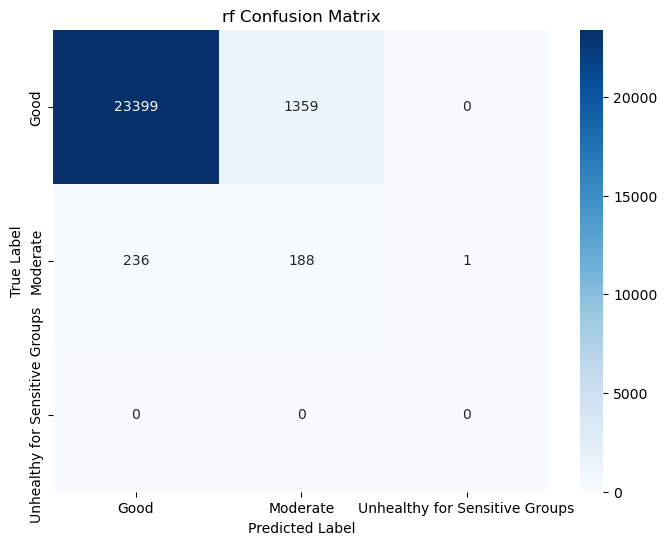

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Convert y_test from one-hot encoding to integer labels
y_test_labels = np.argmax(y_test, axis=1)

# 2. Generate the confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_rf)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('rf Confusion Matrix')
plt.show()